In [1]:
# Base imports and path setting
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import jax
import jax.numpy as jnp
import diffrax as dfx
from time import time

import sys
import os
from os.path import dirname
cwd = os.getcwd()
sys.path.append(dirname(cwd))


In [2]:
# Relative import and macroscopic configs
from src.flows import samelson_flow, trajectory_plot, stream_plot
from src.lyapunov import flow_lyapunov_spectrum, make_batch_lyapunov_solver, kaplan_yorke_dim, boxcount_dimension, poincare_sos

jax.config.update("jax_enable_x64", True)
rng = np.random.default_rng(seed=42069)
FIG_PATH = dirname(cwd) + "/figs/"

In [3]:
# Flow selection and parameters
rhs = samelson_flow
pars = {
    "A0": 1.064,
    "C": 0.25,
    "L": 2,
    "h": 0.07,
    "wf": 0.058,
}

# Initial condition, integration options
z0 = jnp.array([1, 1])
dt = 0.001
N_iters = 2e5
timesteps = np.linspace(0, dt*N_iters, 500000)

steps = 1
burns = 0.2

solver = dfx.Kvaerno5()
stepsc = dfx.PIDController(rtol=1e-8, atol=1e-8)
term = dfx.ODETerm(rhs)
saveat = dfx.SaveAt(ts=timesteps)

# Graph boundaries and grids
X_space = np.linspace(-2*np.pi, 2*np.pi, 400)
Y_space = np.linspace(-5, 5, 400)
X, Y = np.meshgrid(X_space, Y_space)
U, V = rhs(t=0, z=(X, Y), params=pars)

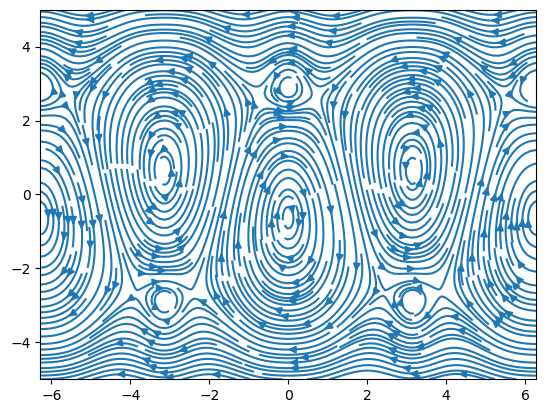

In [4]:
# Animation of the flow
starting_lines = np.array([i.flatten() for i in np.meshgrid(
                            np.linspace(-2*np.pi, 2*np.pi, 200),
                            np.linspace(-5, 5, 200),
                            indexing="ij"
                           )]).T

dens=3

fig, ax = plt.subplots()
stream = ax.streamplot(X, Y, U, V, density=dens, start_points=starting_lines)

def animate(ti):
    ax.clear()
    ax.grid(True)
    U, V = rhs(t=ti, z=(X, Y), params=pars)
    stream = ax.streamplot(X, Y, U, V, density=dens, start_points=starting_lines)
    print(ti)
    return stream

#anim = animation.FuncAnimation(fig, animate, frames=np.linspace(0, 2*np.pi/pars.get("wf", 1), 100), interval=50, blit=False, repeat=False)
#anim.save( FIG_PATH + '/samelson.gif', writer='imagemagick', fps=30)
# plt.show()


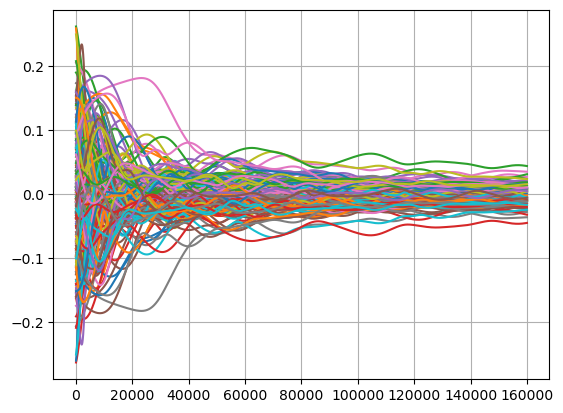

Lyapunov exponent extimate (averaged over random trajectories): [ 0.01101411 -0.01101411] +- [0.0074489 0.0074489]


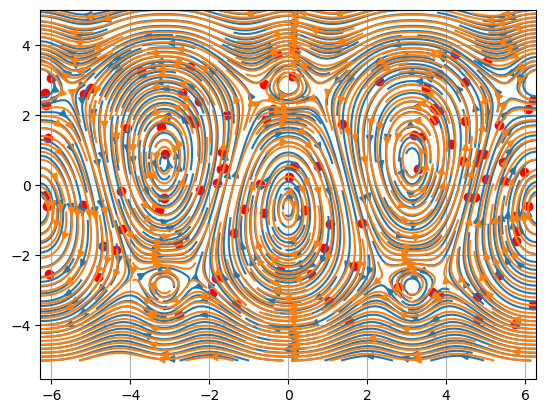

In [6]:
# First experiment: lyapunov exponents for 100 random initial condition
# Confrontation with box counting dimension

# Define random ranges
flurry = jnp.array([rng.random(100)*4*np.pi - 2*np.pi, rng.random(100)*8 - 4]).T
t0_batch = jnp.zeros(len(flurry))

# Build mappable function
compute = make_batch_lyapunov_solver(flow=rhs, solver=solver, dt=dt, stepsize=stepsc, n_intervals=N_iters, burn_in=int(N_iters*burns), jacobian=False)
batched_lyap = jax.jit(
    jax.vmap(compute, in_axes=(0, 0, None, None))
)

# Execute and show results
trajects, cum_lyaps = batched_lyap(flurry, t0_batch, pars, steps*dt)
for cum in cum_lyaps:
    plt.plot(cum)
plt.grid(True)
plt.savefig(FIG_PATH + "Rand_lyaps.png")
plt.show(cwd + '/samelson_lyap100.png')
lyap_ext = cum_lyaps.mean(axis=0)[-1, :]
lyap_std = cum_lyaps.std(axis=0)[-1, :]
print(f"Lyapunov exponent extimate (averaged over random trajectories): {lyap_ext} +- {lyap_std}")

# Flow at different times with flurry
plt.streamplot(X, Y, U , V, density=3)
U, V = rhs(t=np.pi/(2*pars.get("wf")), z=(X, Y), params=pars)
plt.streamplot(X, Y, U , V, density=3)
plt.scatter(*flurry.T, c="red")
plt.grid()
plt.savefig(FIG_PATH + "Flurry_flow.png")
plt.show()


In [ ]:
# Second experiment: parameters variation
